## Project V1 status

This notebook represents the final executive prototype for Project V1.

The data are synthetic and should not be interpreted as real CHO performance data.

The purpose is to demonstrate the end-to-end SDL decision logic:

clone screening → engineering recommendation → risk assessment → simulated experiment → learning feedback → final executive decision.

Future versions should validate the workflow using real CLD, omics, process, and product-quality datasets.

# Notebook24 — SDL Executive Clone Intelligence Platform

## Purpose

This final notebook consolidates the SDL prototype into an executive decision platform.

The goal is to answer the original CLD problem:

Can we identify high-risk false-positive clones early, select true manufacturing candidates, recommend engineering or upstream process strategies, and reduce development time and cost?

This notebook integrates:

- Pareto optimization
- clone screening
- SDL experiment planning
- engineering risk assessment
- experimental outcome simulation
- closed-loop SDL learning

## Main Outputs

The notebook classifies clones into final development archetypes:

- SUPER
- AGGRESSIVE
- DEVELOPMENT
- REJECT

It also generates:

- final clone intelligence table
- false-positive clone list
- upstream process recommendations
- engineering recommendations
- manufacturing candidate ranking
- SDL impact summary

## Section 1 — Load Notebook10–23 outputs

This section loads the key summary outputs from the full SDL workflow.

We do not need every intermediate file because later notebooks already summarize earlier results.

In [14]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve().parents[0]
DT = ROOT / "data/synthetic/digital_twin"
PARETO = ROOT / "data/synthetic/pareto"

def load_csv(path, name):
    if path.exists():
        df = pd.read_csv(path)
        print(f"{name}: {df.shape}")
        return df
    else:
        print(f"{name}: missing")
        return pd.DataFrame()

pareto = load_csv(
    PARETO / "notebook10_final_pareto_recommendations_5000_legacy.csv",
    "Pareto recommendations"
)

dashboard = load_csv(
    DT / "notebook18_candidate_dashboard_5000_legacy.csv",
    "Notebook18 dashboard"
)

sdl_batch = load_csv(
    DT / "notebook19_sdl_experiment_batch_5000_legacy.csv",
    "Notebook19 SDL batch"
)

risk = load_csv(
    DT / "notebook21_engineering_risk_assessment_5000_legacy.csv",
    "Notebook21 risk assessment"
)

outcomes = load_csv(
    DT / "notebook22_engineering_experimental_outcomes_5000_legacy.csv",
    "Notebook22 experimental outcomes"
)

learning = load_csv(
    DT / "notebook23_sdl_learning_database_5000_legacy.csv",
    "Notebook23 learning database"
)

knowledge = load_csv(
    DT / "notebook23_intervention_knowledge_updates_5000_legacy.csv",
    "Notebook23 knowledge updates"
)

Pareto recommendations: (92, 18)
Notebook18 dashboard: (94, 8)
Notebook19 SDL batch: (20, 14)
Notebook21 risk assessment: (36, 20)
Notebook22 experimental outcomes: (36, 40)
Notebook23 learning database: (36, 44)
Notebook23 knowledge updates: (2, 11)


## Section 2 — Build integrated clone intelligence table

This section creates a single master table.

The master table combines clone-level outputs from Pareto optimization, candidate screening, engineering simulation, and SDL learning.

In [15]:
def prefix_except_id(df, prefix):
    if df.empty or "clone_id" not in df.columns:
        return df

    renamed = {
        c: f"{prefix}_{c}"
        for c in df.columns
        if c != "clone_id"
    }

    return df.rename(columns=renamed)


def make_clone_level(df, name, score_col=None):
    """
    Make one row per clone_id before merging.
    If score_col is available, keep the best row per clone.
    Otherwise, keep the first row.
    """
    if df.empty:
        return df

    if "clone_id" not in df.columns:
        print(f"{name}: no clone_id column")
        return df

    before = df.shape[0]

    if score_col is not None and score_col in df.columns:
        df = (
            df
            .sort_values(score_col, ascending=False)
            .drop_duplicates("clone_id", keep="first")
        )
    else:
        df = df.drop_duplicates("clone_id", keep="first")

    after = df.shape[0]

    print(f"{name}: {before} rows → {after} unique clones")

    return df


# Make all clone-level tables unique before merging
outcomes_u = make_clone_level(
    outcomes,
    "Notebook22 outcomes",
    score_col="experimental_roi_score"
)

dashboard_u = make_clone_level(
    dashboard,
    "Notebook18 dashboard",
    score_col="overall_score"
)

risk_u = make_clone_level(
    risk,
    "Notebook21 risk",
    score_col="expected_net_benefit"
)

learning_u = make_clone_level(
    learning,
    "Notebook23 learning",
    score_col="observed_score"
)

pareto_u = make_clone_level(
    pareto,
    "Notebook10 Pareto"
)


# Start from Notebook22 because it contains the final experimental-style metrics
master = outcomes_u.copy()

if "clone_id" not in master.columns:
    raise ValueError("Notebook22 outcomes must contain clone_id.")


if not dashboard_u.empty and "clone_id" in dashboard_u.columns:
    master = master.merge(
        prefix_except_id(dashboard_u, "nb18"),
        on="clone_id",
        how="left"
    )


if not risk_u.empty and "clone_id" in risk_u.columns:
    master = master.merge(
        prefix_except_id(risk_u, "risk"),
        on="clone_id",
        how="left"
    )


if not learning_u.empty and "clone_id" in learning_u.columns:
    master = master.merge(
        prefix_except_id(learning_u, "learn"),
        on="clone_id",
        how="left"
    )


if not pareto_u.empty and "clone_id" in pareto_u.columns:
    pareto_ids = pareto_u[["clone_id"]].drop_duplicates().copy()
    pareto_ids["pareto_selected"] = 1

    master = master.merge(
        pareto_ids,
        on="clone_id",
        how="left"
    )
else:
    master["pareto_selected"] = 0


master["pareto_selected"] = (
    master["pareto_selected"]
    .fillna(0)
    .astype(int)
)

print("Final integrated clone-level table:", master.shape)
print("Unique clone IDs:", master["clone_id"].nunique())

display(master.head())

Notebook22 outcomes: 36 rows → 33 unique clones
Notebook18 dashboard: 94 rows → 91 unique clones
Notebook21 risk: 36 rows → 33 unique clones
Notebook23 learning: 36 rows → 33 unique clones
Notebook10 Pareto: 92 rows → 91 unique clones
Final integrated clone-level table: (33, 110)
Unique clone IDs: 33


,clone_id,overall_score,score_productivity,score_quality,score_stability,omics_score,rl_robustness_score,decision,bottleneck,recommended_intervention,...,learn_delta_qp_pg_cell_day,learn_delta_stability_pct,learn_delta_quality_pct,learn_experimental_roi_score,learn_engineering_result_class,learn_predicted_score,learn_observed_score,learn_prediction_error,learn_observed_success,pareto_selected
0,CLONE_1091,36.186520,0.054766,81.823528,83.123424,17.252199,57.167017,Engineer,productivity,XBP1s_secretory_support,...,3.064123,-0.503416,-1.646296,4.995627,Moderate Improvement,56.391077,61.386703,4.995627,1,1
1,CLONE_0080,42.126019,0.296049,89.439926,88.808949,27.907134,72.044430,Advance with Monitoring,productivity,XBP1s_secretory_support,...,1.049292,0.837641,-0.088541,4.013603,Moderate Improvement,61.784445,65.798048,4.013603,1,1
2,CLONE_3895,42.631425,1.170372,98.607662,82.267468,28.517580,78.902602,Advance with Monitoring,productivity,XBP1s_secretory_support,...,0.957294,1.432854,-0.089771,2.963176,Neutral / Small Change,62.177485,65.140661,2.963176,0,1
3,CLONE_0894,38.457279,3.201971,77.531609,88.887262,18.321968,74.309556,Engineer,productivity,XBP1s_secretory_support,...,1.691237,0.969901,3.235683,2.079992,Neutral / Small Change,55.585774,57.665766,2.079992,0,1
4,CLONE_3527,36.411369,2.716302,85.780479,86.048849,18.260071,61.283097,Engineer,productivity,XBP1s_secretory_support,...,3.835314,0.069032,-0.283092,2.075138,Neutral / Small Change,52.327982,54.403119,2.075138,0,1


## Section 3 — Calculate final composite score

The final score integrates multiple decision dimensions:

- productivity
- qP
- stability
- quality
- engineering ROI
- Pareto selection
- SDL learning confidence

This score is not a biological measurement. It is a decision-support score.

In [16]:
def normalize_0_100(series):
    series = pd.to_numeric(series, errors="coerce")
    min_v = series.min()
    max_v = series.max()
    if pd.isna(min_v) or pd.isna(max_v) or max_v == min_v:
        return pd.Series(50, index=series.index)
    return 100 * (series - min_v) / (max_v - min_v)

required_metric_cols = [
    "titer_after_g_L",
    "qp_after_pg_cell_day",
    "stability_after_pct",
    "quality_after_pct",
    "experimental_roi_score",
]

missing = [c for c in required_metric_cols if c not in master.columns]
if missing:
    raise ValueError(f"Missing required Notebook22 columns: {missing}")

master["score_titer_final"] = normalize_0_100(master["titer_after_g_L"])
master["score_qp_final"] = normalize_0_100(master["qp_after_pg_cell_day"])
master["score_stability_final"] = normalize_0_100(master["stability_after_pct"])
master["score_quality_final"] = normalize_0_100(master["quality_after_pct"])
master["score_roi_final"] = normalize_0_100(master["experimental_roi_score"])

master["score_pareto_final"] = master["pareto_selected"] * 100

if "learn_prediction_error" in master.columns:
    master["score_learning_final"] = (
        100 - normalize_0_100(master["learn_prediction_error"].abs())
    )
else:
    master["score_learning_final"] = 50

master["final_sdl_score"] = (
    0.20 * master["score_titer_final"]
    + 0.15 * master["score_qp_final"]
    + 0.20 * master["score_stability_final"]
    + 0.15 * master["score_quality_final"]
    + 0.10 * master["score_roi_final"]
    + 0.10 * master["score_pareto_final"]
    + 0.10 * master["score_learning_final"]
)

display(
    master[
        [
            "clone_id",
            "final_sdl_score",
            "titer_after_g_L",
            "qp_after_pg_cell_day",
            "stability_after_pct",
            "quality_after_pct",
            "experimental_roi_score",
            "pareto_selected",
        ]
    ]
    .sort_values("final_sdl_score", ascending=False)
    .head(15)
)

,clone_id,final_sdl_score,titer_after_g_L,qp_after_pg_cell_day,stability_after_pct,quality_after_pct,experimental_roi_score,pareto_selected
6,CLONE_4625,73.814886,6.882502,41.701048,91.539428,87.838499,1.894724,1
9,CLONE_1371,59.036982,1.523233,7.776494,99.131277,95.293461,0.878051,1
14,CLONE_1591,56.882645,1.122821,12.134722,95.510417,100.000000,-0.720687,1
3,CLONE_0894,56.393969,1.915392,11.939220,95.773596,95.179871,2.079992,1
2,CLONE_3895,55.206712,2.370905,9.725536,94.338296,96.272419,2.963176,1
12,CLONE_3826,55.012876,1.231009,14.168191,98.137052,88.732606,0.030381,1
13,CLONE_3007,53.624050,1.433491,7.791544,99.556109,89.207958,-0.672052,1
1,CLONE_0080,51.793738,2.484200,8.912731,94.768563,92.091506,4.013603,1
16,CLONE_3546,50.527144,1.781802,8.755630,97.895276,87.124124,-0.984087,1
5,CLONE_1437,48.790084,2.014555,12.692175,91.516147,91.796612,2.060476,1


## Section 4 — Pareto contribution analysis

Pareto optimization helps identify clones that balance multiple objectives.

This section checks whether Pareto-selected clones are enriched among top final SDL candidates.

,final_sdl_score,titer_after_g_L,stability_after_pct,quality_after_pct,experimental_roi_score
pareto_selected,,,,,
1,45.471,1.889,92.579,90.29,-0.589


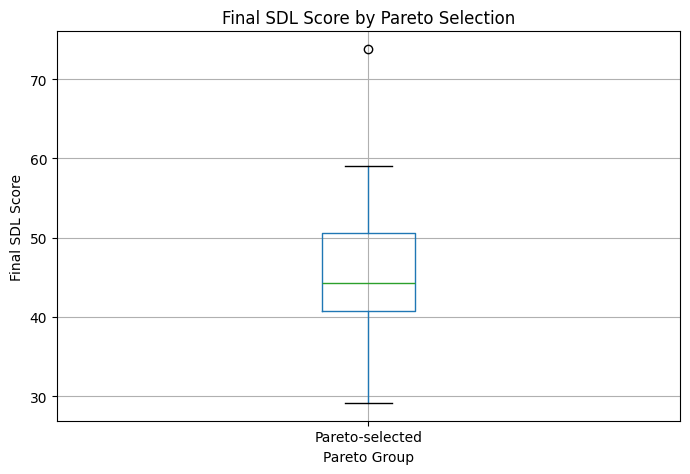

In [17]:
pareto_summary = (
    master
    .groupby("pareto_selected")
    [
        [
            "final_sdl_score",
            "titer_after_g_L",
            "stability_after_pct",
            "quality_after_pct",
            "experimental_roi_score",
        ]
    ]
    .mean()
    .round(3)
)

display(pareto_summary)

master["pareto_label"] = np.where(
    master["pareto_selected"] == 1,
    "Pareto-selected",
    "Non-Pareto"
)

master.boxplot(
    column="final_sdl_score",
    by="pareto_label",
    figsize=(7, 5)
)

plt.title("Final SDL Score by Pareto Selection")
plt.suptitle("")
plt.xlabel("Pareto Group")
plt.ylabel("Final SDL Score")
plt.tight_layout()
plt.show()

## Section 5 — Clone archetype classification

This section classifies clones into final development archetypes.

SUPER clones are strong manufacturing candidates.

AGGRESSIVE clones are high-productivity false positives that may fail because of instability or quality risk.

DEVELOPMENT clones require optimization or engineering.

REJECT clones are low-priority candidates.

In [18]:
# Absolute biological-style thresholds
SUPER_TITER_MIN = 4.5          # g/L
SUPER_QP_MIN = 25              # pg/cell/day
SUPER_STABILITY_MIN = 85       # %
SUPER_QUALITY_MIN = 85         # %

AGGRESSIVE_TITER_MIN = 4.5     # high productivity
AGGRESSIVE_STABILITY_MAX = 80  # insufficient stability
AGGRESSIVE_QUALITY_MAX = 80    # insufficient quality

DEVELOPMENT_SCORE_MIN = master["final_sdl_score"].quantile(0.50)


def classify_clone_absolute(row):
    """
    SUPER:
    High titer, high qP, high stability, high quality.

    AGGRESSIVE:
    High titer but weak stability or quality.
    This represents false-positive CLD risk.

    DEVELOPMENT:
    Reasonable overall score but needs engineering/process optimization.

    REJECT:
    Low priority.
    """

    is_super = (
        row["titer_after_g_L"] >= SUPER_TITER_MIN
        and row["qp_after_pg_cell_day"] >= SUPER_QP_MIN
        and row["stability_after_pct"] >= SUPER_STABILITY_MIN
        and row["quality_after_pct"] >= SUPER_QUALITY_MIN
    )

    is_aggressive = (
        row["titer_after_g_L"] >= AGGRESSIVE_TITER_MIN
        and (
            row["stability_after_pct"] < AGGRESSIVE_STABILITY_MAX
            or row["quality_after_pct"] < AGGRESSIVE_QUALITY_MAX
        )
    )

    if is_super:
        return "SUPER"

    if is_aggressive:
        return "AGGRESSIVE"

    if row["final_sdl_score"] >= DEVELOPMENT_SCORE_MIN:
        return "DEVELOPMENT"

    return "REJECT"


master["clone_archetype"] = master.apply(
    classify_clone_absolute,
    axis=1
)


def explain_clone_class(row):
    if row["clone_archetype"] == "SUPER":
        return "High titer, high qP, stable, and strong quality"

    if row["clone_archetype"] == "AGGRESSIVE":
        return "High productivity but stability or quality risk"

    if row["clone_archetype"] == "DEVELOPMENT":
        return "Moderate candidate requiring engineering or process optimization"

    return "Low priority based on final SDL profile"


master["clone_archetype_reason"] = master.apply(
    explain_clone_class,
    axis=1
)

display(master["clone_archetype"].value_counts())

display(
    master[
        [
            "clone_id",
            "clone_archetype",
            "clone_archetype_reason",
            "titer_after_g_L",
            "qp_after_pg_cell_day",
            "stability_after_pct",
            "quality_after_pct",
            "final_sdl_score",
        ]
    ]
    .sort_values("final_sdl_score", ascending=False)
    .head(20)
)

clone_archetype
REJECT         16
DEVELOPMENT    16
SUPER           1
Name: count, dtype: int64

,clone_id,clone_archetype,clone_archetype_reason,titer_after_g_L,qp_after_pg_cell_day,stability_after_pct,quality_after_pct,final_sdl_score
6,CLONE_4625,SUPER,"High titer, high qP, stable, and strong quality",6.882502,41.701048,91.539428,87.838499,73.814886
9,CLONE_1371,DEVELOPMENT,Moderate candidate requiring engineering or pr...,1.523233,7.776494,99.131277,95.293461,59.036982
14,CLONE_1591,DEVELOPMENT,Moderate candidate requiring engineering or pr...,1.122821,12.134722,95.510417,100.000000,56.882645
3,CLONE_0894,DEVELOPMENT,Moderate candidate requiring engineering or pr...,1.915392,11.939220,95.773596,95.179871,56.393969
2,CLONE_3895,DEVELOPMENT,Moderate candidate requiring engineering or pr...,2.370905,9.725536,94.338296,96.272419,55.206712
12,CLONE_3826,DEVELOPMENT,Moderate candidate requiring engineering or pr...,1.231009,14.168191,98.137052,88.732606,55.012876
13,CLONE_3007,DEVELOPMENT,Moderate candidate requiring engineering or pr...,1.433491,7.791544,99.556109,89.207958,53.624050
1,CLONE_0080,DEVELOPMENT,Moderate candidate requiring engineering or pr...,2.484200,8.912731,94.768563,92.091506,51.793738
16,CLONE_3546,DEVELOPMENT,Moderate candidate requiring engineering or pr...,1.781802,8.755630,97.895276,87.124124,50.527144
5,CLONE_1437,DEVELOPMENT,Moderate candidate requiring engineering or pr...,2.014555,12.692175,91.516147,91.796612,48.790084


## Section 6 — False-positive clone identification

False-positive clones are dangerous in CLD.

They appear productive early but have poor stability or quality, making them risky for late-stage development.

This section identifies aggressive clones.

In [19]:
false_positive_clones = (
    master[
        master["clone_archetype"] == "AGGRESSIVE"
    ]
    .sort_values("titer_after_g_L", ascending=False)
)

display(
    false_positive_clones[
        [
            "clone_id",
            "clone_archetype",
            "titer_after_g_L",
            "qp_after_pg_cell_day",
            "stability_after_pct",
            "quality_after_pct",
            "final_sdl_score",
            "experimental_roi_score",
        ]
    ]
    .head(20)
)

,clone_id,clone_archetype,titer_after_g_L,qp_after_pg_cell_day,stability_after_pct,quality_after_pct,final_sdl_score,experimental_roi_score


## Section 7 — Engineering recommendation summary

This section summarizes recommended engineering strategies across the final clone portfolio.

recommended_intervention
XBP1s_secretory_support    31
PDI_folding_support         2
Name: count, dtype: int64

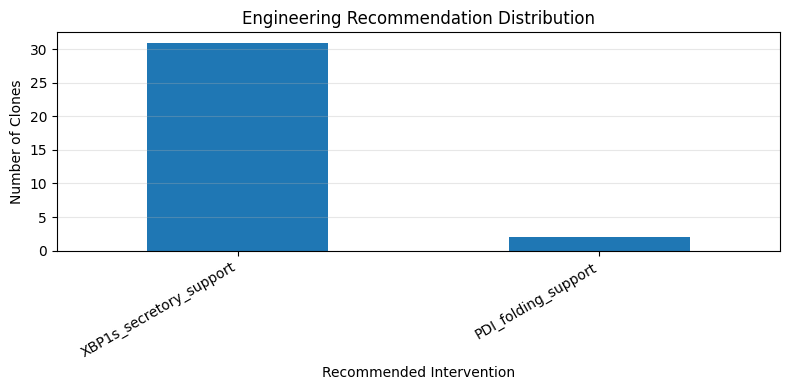

In [20]:
if "recommended_intervention" in master.columns:
    intervention_counts = master["recommended_intervention"].value_counts()

    display(intervention_counts)

    intervention_counts.plot.bar(figsize=(8, 4))

    plt.title("Engineering Recommendation Distribution")
    plt.xlabel("Recommended Intervention")
    plt.ylabel("Number of Clones")
    plt.xticks(rotation=30, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("recommended_intervention column not available.")

## Section 8 — Titer improvement dashboard

This plot compares before- and after-engineering titer.

Points above the diagonal improved after engineering.

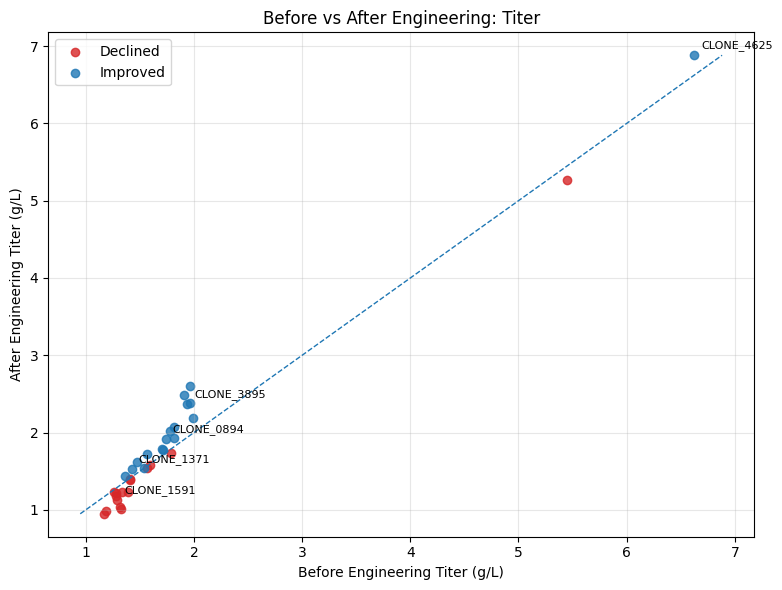

In [21]:
plot_df = master.copy()

plot_df["titer_response"] = np.where(
    plot_df["titer_after_g_L"] >= plot_df["titer_before_g_L"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("titer_response"):
    plt.scatter(
        group["titer_before_g_L"],
        group["titer_after_g_L"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["titer_before_g_L"].min(),
    plot_df["titer_after_g_L"].min(),
)

max_val = max(
    plot_df["titer_before_g_L"].max(),
    plot_df["titer_after_g_L"].max(),
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

for _, row in plot_df.sort_values("final_sdl_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (row["titer_before_g_L"], row["titer_after_g_L"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: Titer")
plt.xlabel("Before Engineering Titer (g/L)")
plt.ylabel("After Engineering Titer (g/L)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 9 — qP improvement dashboard

This plot compares before- and after-engineering specific productivity.

qP is important because it reflects productivity per cell.

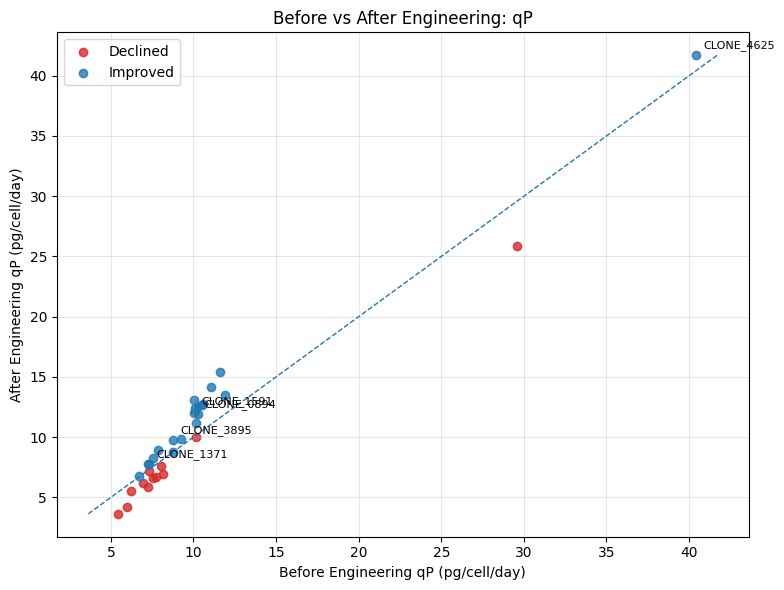

In [22]:
plot_df = master.copy()

plot_df["qp_response"] = np.where(
    plot_df["qp_after_pg_cell_day"] >= plot_df["qp_before_pg_cell_day"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("qp_response"):
    plt.scatter(
        group["qp_before_pg_cell_day"],
        group["qp_after_pg_cell_day"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["qp_before_pg_cell_day"].min(),
    plot_df["qp_after_pg_cell_day"].min(),
)

max_val = max(
    plot_df["qp_before_pg_cell_day"].max(),
    plot_df["qp_after_pg_cell_day"].max(),
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

for _, row in plot_df.sort_values("final_sdl_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (row["qp_before_pg_cell_day"], row["qp_after_pg_cell_day"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: qP")
plt.xlabel("Before Engineering qP (pg/cell/day)")
plt.ylabel("After Engineering qP (pg/cell/day)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 10 — Quality improvement dashboard

This plot compares before- and after-engineering product quality.

Quality is essential for manufacturability and regulatory success.

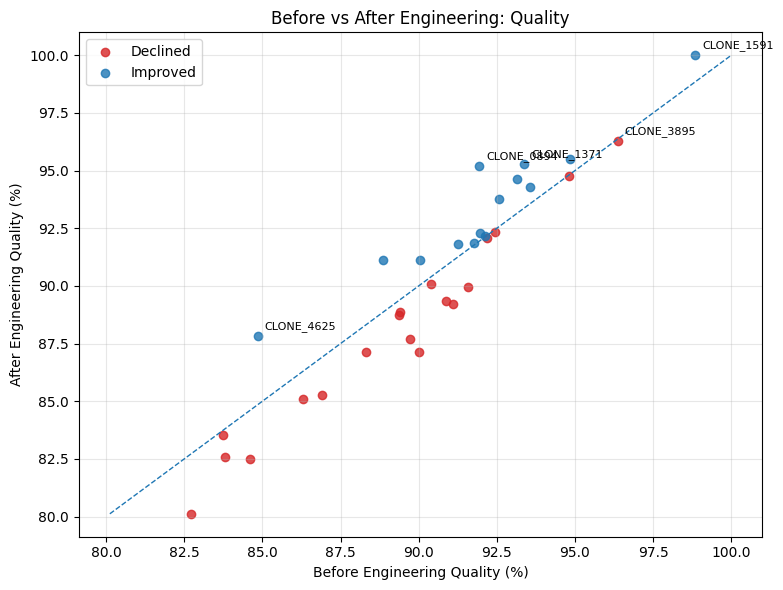

In [23]:
plot_df = master.copy()

plot_df["quality_response"] = np.where(
    plot_df["quality_after_pct"] >= plot_df["quality_before_pct"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("quality_response"):
    plt.scatter(
        group["quality_before_pct"],
        group["quality_after_pct"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["quality_before_pct"].min(),
    plot_df["quality_after_pct"].min(),
)

max_val = max(
    plot_df["quality_before_pct"].max(),
    plot_df["quality_after_pct"].max(),
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

for _, row in plot_df.sort_values("final_sdl_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (row["quality_before_pct"], row["quality_after_pct"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: Quality")
plt.xlabel("Before Engineering Quality (%)")
plt.ylabel("After Engineering Quality (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 11 — Stability improvement dashboard

This plot compares before- and after-engineering stability.

Stable clones are more reliable during scale-up and long-term manufacturing.

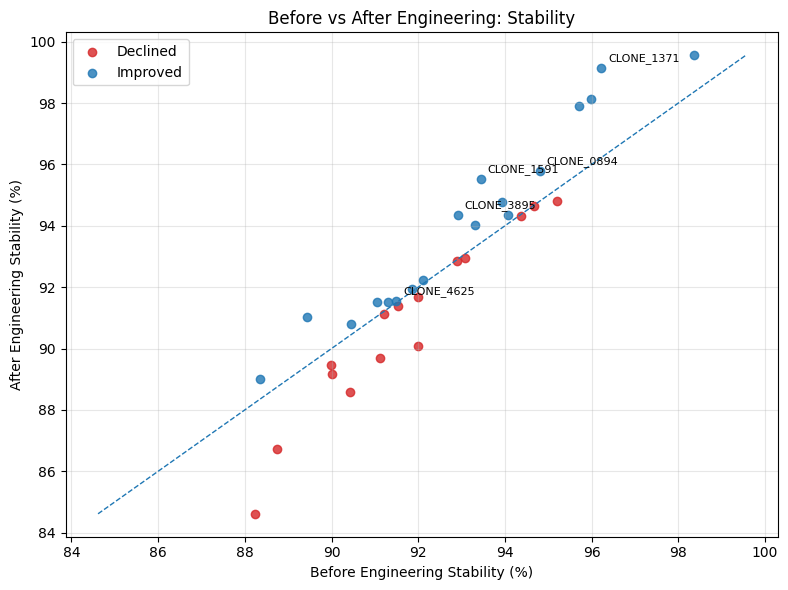

In [24]:
plot_df = master.copy()

plot_df["stability_response"] = np.where(
    plot_df["stability_after_pct"] >= plot_df["stability_before_pct"],
    "Improved",
    "Declined",
)

color_map = {
    "Improved": "tab:blue",
    "Declined": "tab:red",
}

plt.figure(figsize=(8, 6))

for label, group in plot_df.groupby("stability_response"):
    plt.scatter(
        group["stability_before_pct"],
        group["stability_after_pct"],
        label=label,
        alpha=0.8,
        c=color_map[label],
    )

min_val = min(
    plot_df["stability_before_pct"].min(),
    plot_df["stability_after_pct"].min(),
)

max_val = max(
    plot_df["stability_before_pct"].max(),
    plot_df["stability_after_pct"].max(),
)

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--", linewidth=1)

for _, row in plot_df.sort_values("final_sdl_score", ascending=False).head(5).iterrows():
    plt.annotate(
        row["clone_id"],
        (row["stability_before_pct"], row["stability_after_pct"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.title("Before vs After Engineering: Stability")
plt.xlabel("Before Engineering Stability (%)")
plt.ylabel("After Engineering Stability (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Section 12 — Upstream process recommendation engine

This section converts clone archetype and bottleneck information into practical upstream process recommendations.

In [25]:
# Safety check for final score column

if "final_sdl_score" not in master.columns:
    if "final_score" in master.columns:
        master["final_sdl_score"] = master["final_score"]
    else:
        raise KeyError(
            "Neither 'final_sdl_score' nor 'final_score' exists. "
            "Please rerun Section 3 — Calculate final composite score."
        )

print("Score column ready:", "final_sdl_score" in master.columns)

Score column ready: True


In [26]:
def recommend_upstream_process(row):
    if row["clone_archetype"] == "SUPER":
        return "Standard Fed-Batch Scale-Up"

    if row["clone_archetype"] == "AGGRESSIVE":
        return "Enhanced Monitoring + Short Campaign"

    if row["quality_after_pct"] < AGGRESSIVE_QUALITY_MAX:
        return "Quality-Focused Process Optimization"

    if row["stability_after_pct"] < AGGRESSIVE_STABILITY_MAX:
        return "Low-Stress Stability-Focused Process"

    if row["experimental_roi_score"] > 0:
        return "Engineering-Supported Fed-Batch"

    return "Hold / Reassess"


master["upstream_process_strategy"] = master.apply(
    recommend_upstream_process,
    axis=1,
)

display(
    master[
        [
            "clone_id",
            "clone_archetype",
            "clone_archetype_reason",
            "recommended_intervention",
            "upstream_process_strategy",
            "final_sdl_score",
        ]
    ]
    .sort_values("final_sdl_score", ascending=False)
    .head(20)
)

,clone_id,clone_archetype,clone_archetype_reason,recommended_intervention,upstream_process_strategy,final_sdl_score
6,CLONE_4625,SUPER,"High titer, high qP, stable, and strong quality",PDI_folding_support,Standard Fed-Batch Scale-Up,73.814886
9,CLONE_1371,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Engineering-Supported Fed-Batch,59.036982
14,CLONE_1591,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Hold / Reassess,56.882645
3,CLONE_0894,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Engineering-Supported Fed-Batch,56.393969
2,CLONE_3895,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Engineering-Supported Fed-Batch,55.206712
12,CLONE_3826,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Engineering-Supported Fed-Batch,55.012876
13,CLONE_3007,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Hold / Reassess,53.624050
1,CLONE_0080,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Engineering-Supported Fed-Batch,51.793738
16,CLONE_3546,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Hold / Reassess,50.527144
5,CLONE_1437,DEVELOPMENT,Moderate candidate requiring engineering or pr...,XBP1s_secretory_support,Engineering-Supported Fed-Batch,48.790084


## Section 13 — Top manufacturing candidates

This section identifies the strongest final manufacturing candidates.

These clones combine productivity, quality, stability, Pareto fitness, and SDL learning evidence.

In [27]:
top_candidates = (
    master
    .sort_values("final_sdl_score", ascending=False)
    .head(15)
)

display(
    top_candidates[
        [
            "clone_id",
            "clone_archetype",
            "clone_archetype_reason",
            "final_sdl_score",
            "titer_after_g_L",
            "qp_after_pg_cell_day",
            "stability_after_pct",
            "quality_after_pct",
            "recommended_intervention",
            "upstream_process_strategy",
            "pareto_selected",
            "experimental_roi_score",
        ]
    ]
    .round(3)
)

,clone_id,clone_archetype,clone_archetype_reason,final_sdl_score,titer_after_g_L,qp_after_pg_cell_day,stability_after_pct,quality_after_pct,recommended_intervention,upstream_process_strategy,pareto_selected,experimental_roi_score
6,CLONE_4625,SUPER,"High titer, high qP, stable, and strong quality",73.815,6.883,41.701,91.539,87.838,PDI_folding_support,Standard Fed-Batch Scale-Up,1,1.895
9,CLONE_1371,DEVELOPMENT,Moderate candidate requiring engineering or pr...,59.037,1.523,7.776,99.131,95.293,XBP1s_secretory_support,Engineering-Supported Fed-Batch,1,0.878
14,CLONE_1591,DEVELOPMENT,Moderate candidate requiring engineering or pr...,56.883,1.123,12.135,95.510,100.000,XBP1s_secretory_support,Hold / Reassess,1,-0.721
3,CLONE_0894,DEVELOPMENT,Moderate candidate requiring engineering or pr...,56.394,1.915,11.939,95.774,95.180,XBP1s_secretory_support,Engineering-Supported Fed-Batch,1,2.080
2,CLONE_3895,DEVELOPMENT,Moderate candidate requiring engineering or pr...,55.207,2.371,9.726,94.338,96.272,XBP1s_secretory_support,Engineering-Supported Fed-Batch,1,2.963
12,CLONE_3826,DEVELOPMENT,Moderate candidate requiring engineering or pr...,55.013,1.231,14.168,98.137,88.733,XBP1s_secretory_support,Engineering-Supported Fed-Batch,1,0.030
13,CLONE_3007,DEVELOPMENT,Moderate candidate requiring engineering or pr...,53.624,1.433,7.792,99.556,89.208,XBP1s_secretory_support,Hold / Reassess,1,-0.672
1,CLONE_0080,DEVELOPMENT,Moderate candidate requiring engineering or pr...,51.794,2.484,8.913,94.769,92.092,XBP1s_secretory_support,Engineering-Supported Fed-Batch,1,4.014
16,CLONE_3546,DEVELOPMENT,Moderate candidate requiring engineering or pr...,50.527,1.782,8.756,97.895,87.124,XBP1s_secretory_support,Hold / Reassess,1,-0.984
5,CLONE_1437,DEVELOPMENT,Moderate candidate requiring engineering or pr...,48.790,2.015,12.692,91.516,91.797,XBP1s_secretory_support,Engineering-Supported Fed-Batch,1,2.060


## Section 14 — Executive scorecard

This scorecard summarizes average performance by clone archetype.

It provides a compact executive view of the final SDL decision landscape.

In [28]:
executive_scorecard = (
    master
    .groupby("clone_archetype")
    .agg(
        n=("clone_id", "count"),
        mean_final_score=("final_sdl_score", "mean"),
        mean_titer=("titer_after_g_L", "mean"),
        mean_qp=("qp_after_pg_cell_day", "mean"),
        mean_stability=("stability_after_pct", "mean"),
        mean_quality=("quality_after_pct", "mean"),
        mean_roi=("experimental_roi_score", "mean"),
        pareto_rate=("pareto_selected", "mean"),
    )
    .round(3)
)

display(executive_scorecard)

,n,mean_final_score,mean_titer,mean_qp,mean_stability,mean_quality,mean_roi,pareto_rate
clone_archetype,,,,,,,,
DEVELOPMENT,16,50.753,1.804,9.678,94.456,91.964,0.571,1.0
REJECT,16,38.418,1.663,10.183,90.766,88.769,-1.903,1.0
SUPER,1,73.815,6.883,41.701,91.539,87.838,1.895,1.0


## Section 15 — SDL impact assessment

This section estimates the portfolio-level value of the SDL workflow.

The goal is to understand how much experimental burden can be reduced by screening and prioritizing clones computationally before expensive wet-lab validation.

Key questions:

- How much did the SDL workflow reduce experimental burden?
- How many clones were eliminated before expensive testing?
- How many high-value candidates remain after SDL-guided selection?

This section translates technical clone screening into business impact.

In [29]:
starting_clones = 5000
evaluated_candidates = master["clone_id"].nunique()
super_clones = int((master["clone_archetype"] == "SUPER").sum())
aggressive_clones = int((master["clone_archetype"] == "AGGRESSIVE").sum())

sdl_impact = pd.DataFrame(
    {
        "metric": [
            "starting_clone_pool",
            "unique_evaluated_final_candidates",
            "super_clone_candidates",
            "aggressive_false_positive_candidates",
            "screening_reduction_to_final_candidates",
            "screening_reduction_to_super_clones",
        ],
        "value": [
            starting_clones,
            evaluated_candidates,
            super_clones,
            aggressive_clones,
            round(1 - evaluated_candidates / starting_clones, 4),
            round(1 - max(super_clones, 1) / starting_clones, 4),
        ],
    }
)

display(sdl_impact)

,metric,value
0,starting_clone_pool,5000.0000
1,unique_evaluated_final_candidates,33.0000
2,super_clone_candidates,1.0000
3,aggressive_false_positive_candidates,0.0000
4,screening_reduction_to_final_candidates,0.9934
5,screening_reduction_to_super_clones,0.9998


## Section 16 — Final platform recommendation

This section summarizes the final platform-level recommendation.

It shows how many clones should be advanced, engineered, monitored, or rejected.

final_platform_recommendation
Reject                            16
Engineer / Optimize               16
Advance to Process Development     1
Name: count, dtype: int64

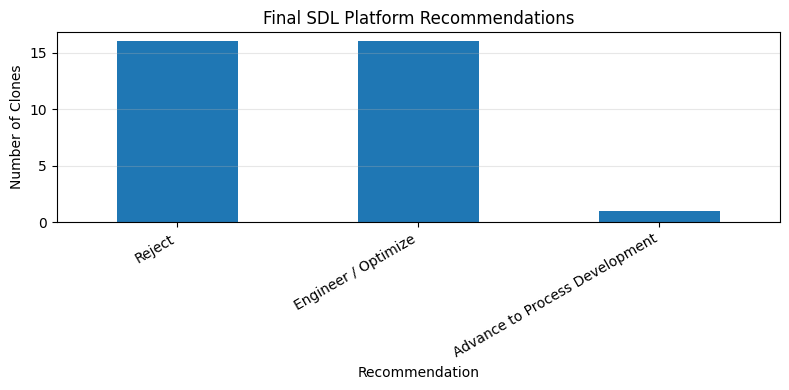

In [30]:
def final_recommendation(row):
    if row["clone_archetype"] == "SUPER":
        return "Advance to Process Development"

    if row["clone_archetype"] == "AGGRESSIVE":
        return "Monitor as False Positive Risk"

    if row["clone_archetype"] == "DEVELOPMENT":
        return "Engineer / Optimize"

    return "Reject"

master["final_platform_recommendation"] = master.apply(
    final_recommendation,
    axis=1,
)

recommendation_counts = master["final_platform_recommendation"].value_counts()

display(recommendation_counts)

recommendation_counts.plot.bar(figsize=(8, 4))

plt.title("Final SDL Platform Recommendations")
plt.xlabel("Recommendation")
plt.ylabel("Number of Clones")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Section 17 — Export executive datasets

This final section exports the Notebook24 executive outputs.

These files represent the final Project V1 deliverables.

In [31]:
out_dir = DT

master.to_csv(
    out_dir / "notebook24_clone_intelligence_platform_5000_legacy.csv",
    index=False,
)

top_candidates.to_csv(
    out_dir / "notebook24_top_manufacturing_candidates_5000_legacy.csv",
    index=False,
)

executive_scorecard.to_csv(
    out_dir / "notebook24_executive_scorecard_5000_legacy.csv",
)

sdl_impact.to_csv(
    out_dir / "notebook24_sdl_impact_summary_5000_legacy.csv",
    index=False,
)

false_positive_clones.to_csv(
    out_dir / "notebook24_aggressive_false_positive_clones_5000_legacy.csv",
    index=False,
)

print("Notebook24 executive outputs saved.")

Notebook24 executive outputs saved.


# Final Summary

Notebook24 integrated the full Project V1 SDL workflow into an executive clone intelligence platform.

The notebook combined:

- Pareto optimization
- clone screening
- engineering recommendation
- risk assessment
- experimental outcome simulation
- closed-loop SDL learning

The final platform classified clones into:

- SUPER
- AGGRESSIVE
- DEVELOPMENT
- REJECT

The notebook also identified false-positive aggressive clones, recommended upstream process strategies, ranked final manufacturing candidates, and quantified SDL portfolio impact.

This completes the first Project V1 prototype of an SDL-guided CHO cell line development decision system.

# References

Sutton RS, Barto AG.  
Reinforcement Learning: An Introduction.  
MIT Press, 2018.

Wurm FM.  
Production of recombinant protein therapeutics in cultivated mammalian cells.  
Nature Biotechnology, 2004.  
DOI: 10.1038/nbt1026

Kim JY, Kim YG, Lee GM.  
CHO cells in biotechnology for production of recombinant proteins.  
Current Opinion in Biotechnology, 2012.  
DOI: 10.1016/j.copbio.2011.10.002

Doudna JA, Charpentier E.  
The new frontier of genome engineering with CRISPR-Cas9.  
Science, 2014.  
DOI: 10.1126/science.1258096

MacLeod BP et al.  
Self-driving laboratory for accelerated discovery of thin-film materials.  
Science Advances, 2020.  
DOI: 10.1126/sciadv.aaz8867

FDA.  
PAT — A Framework for Innovative Pharmaceutical Development, Manufacturing, and Quality Assurance.  
2004.